# 单因子评估 — mom_20d

## 实验框架

### 实验目的
对 `mom_20d`（20 日动量）在全市场跑标准评估流程，回答三个问题：

1. **预测力**：因子有没有横截面预测力？（IC、回归 t 检验）
2. **经济价值**：预测力能否转化为收益差？（分层收益、多空收益、Sharpe/Calmar）
3. **稳定性**：信号是否稳定、可调仓、跨年份一致？（IC 衰减、月度热力图、年度业绩、换手率）

### 评估流程
`run_factor_eval()` 内部执行以下步骤：

| 步骤 | 内容 | 输出 |
|------|------|------|
| 0. 样本筛选 | 剔除停牌/缺失/非正市值/上市不足 250 交易日新股 | `universe` 列 |
| 1. 因子构造 | 原始值 → MAD 缩尾 → z-score → 行业+市值中性化 | `factor_industry_size_neutral` |
| 2. 因子分布 | 检查原始/标准化/中性化后的分布形态 | 直方图 + 统计表 |
| 3. IC 分析 | Rank IC、IC 衰减、IC 半衰期 | IC 图 + decay 表 |
| 4. 回归检验 | 每期 OLS `fwd_return ~ factor`，t 值统计 | t 值图 + mean|t|/|t|>2% |
| 5. 月度 IC | 年×月热力图，发现季节性失效 | 热力图 |
| 6. 分层收益 | Q1~Q5 分组收益、累计收益曲线 | 分组柱状图 + 累计曲线 |
| 7. 多空收益 | Q5−Q1 日度 spread、累计 spread、Sharpe/Calmar | 多空图 + 综合评价 |
| 8. 换手率 | 各分组的日均换手率 | 换手曲线 |
| 9. 年度业绩 | 每年 IC、Q5 收益、胜率 | 年度柱状图 |
| 10. 轻量回测 | Q5 等权做多、5 日调仓、扣交易成本 | 净值曲线 + 回撤 + 换手 |
| 11. 评分卡 | 汇总全部指标 → Pass/Weak/Review 判定 | 评分卡 |

### 与 01 notebook 的关系
- 01 是对因子在单个股票池的**手动深度研究**，7 个 step 逐步展开，适合理解每个指标的含义。
- 02 是把同样流程封装进 `run_factor_eval()`，**一键跑完**，适合快速评估和横向对比不同因子。
- 02 额外补充了 01 没有的：回归 t 检验、月度 IC 热力图、Sharpe/Calmar 综合评价、Q5 回测。


## 参数说明

所有关键参数集中在这里，修改后重新运行 notebook 即可。

### 因子参数
| 参数 | 值 | 说明 |
|------|-----|------|
| `FACTOR_NAME` | `mom_20d` | 因子标识名 |
| `window` | 20 | 动量窗口（交易日） |
| 因子公式 | `adj_close_t / adj_close_{t-20} - 1` | 复权收盘价比值减 1 |

### 样本筛选参数
| 参数 | 值 | 说明 |
|------|-----|------|
| `MIN_LISTING_DAYS` | **250** | 剔除上市不足 250 交易日的股票（≈1 年，对标华泰/中金研报标准） |
| `start_date` | `20240101` | 样本起始日期 |
| 停牌 | 剔除 | `is_suspended == True` 的行被过滤 |
| 市值 | 剔除 ≤0 | `total_mv` 缺失或非正被过滤 |
| 复权收盘价 | 剔除缺失 | `adj_close` 为 NaN 被过滤 |

### 因子预处理参数
| 参数 | 值 | 说明 |
|------|-----|------|
| 缩尾 | MAD, n=3 | 3 倍 MAD 偏离外截断 |
| 标准化 | z-score | 每日横截面标准化 |
| 中性化 | 行业+市值 | 对申万一级行业 dummy + log(总市值) 做 OLS，取残差 |

### 评估参数
| 参数 | 值 | 说明 |
|------|-----|------|
| `FWD_COL` | `fwd_5d` | 主评估标签：5 日未来收益 |
| `N_QUANTILES` | 5 | 分层组数 |
| `REBALANCE_STEP` | 5 | 调仓周期（交易日） |
| `ONE_WAY_COST` | 0.001 (0.1%) | 回测单边交易成本 |
| IC 类型 | Rank IC (Spearman) | 排序相关性，对异常值不敏感 |


In [1]:
from pathlib import Path
import sys
import warnings

import pandas as pd
from IPython.display import display, Markdown

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.append(str(ROOT / "src"))

from factor_eval.runner import run_factor_eval
from factor_eval.report import (
    plot_distribution,
    plot_ic,
    plot_ic_decay,
    plot_long_short,
    plot_quantile_returns,
    plot_scorecard,
    plot_yearly_perf,
    plot_monthly_ic_heatmap,
    plot_regression_test,
    plot_backtest,
)
from factor_utils import compute_momentum

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

# ═══════════════════════════════════════════════
# 参数区 —— 所有可调参数集中在这里
# ═══════════════════════════════════════════════

DUCKDB_PATH = ROOT / "data" / "warehouse" / "ashare.duckdb"
START_DATE = "20240101"
FACTOR_NAME = "mom_20d"
FACTOR_KWARGS = {"window": 20, "col_name": "mom_20d"}
MIN_LISTING_DAYS = 250  # 剔除上市不足 250 交易日的股票（≈1 年，对标华泰研报标准）
ONE_WAY_COST = 0.001     # Q5 回测单边交易成本
UNIVERSE = "全市场"
SHOW_PLOTS = True


---
## 1. 运行评估


In [2]:
assert DUCKDB_PATH.exists(), f"DuckDB 文件不存在: {DUCKDB_PATH}"

result = run_factor_eval(
    FACTOR_NAME,
    compute_momentum,
    FACTOR_KWARGS,
    DUCKDB_PATH,
    universe=UNIVERSE,
    start_date=START_DATE,
    min_listing_days=MIN_LISTING_DAYS,
    one_way_cost=ONE_WAY_COST,
)

print(f"股票数: {result.n_stocks:,}  交易日: {result.n_dates}  有效行: {result.n_valid_rows:,}")


股票数: 5,409  交易日: 310  有效行: 1,643,564


---
## 2. 评分卡


In [3]:
display(plot_scorecard(result))


Metric,Value,Judgement
因子名称,mom_20d,-
股票池,全市场,-
样本起始,,-
上市剔除 (交易日),250d,-
样本股票数,"5,409",-
样本交易日数,310,-
Mean IC,-0.0444,Weak
IC IR,-0.512,-
IC Win Rate,29.7%,Weak
IC Half-life,>20d,-


---
## 3. 因子分布


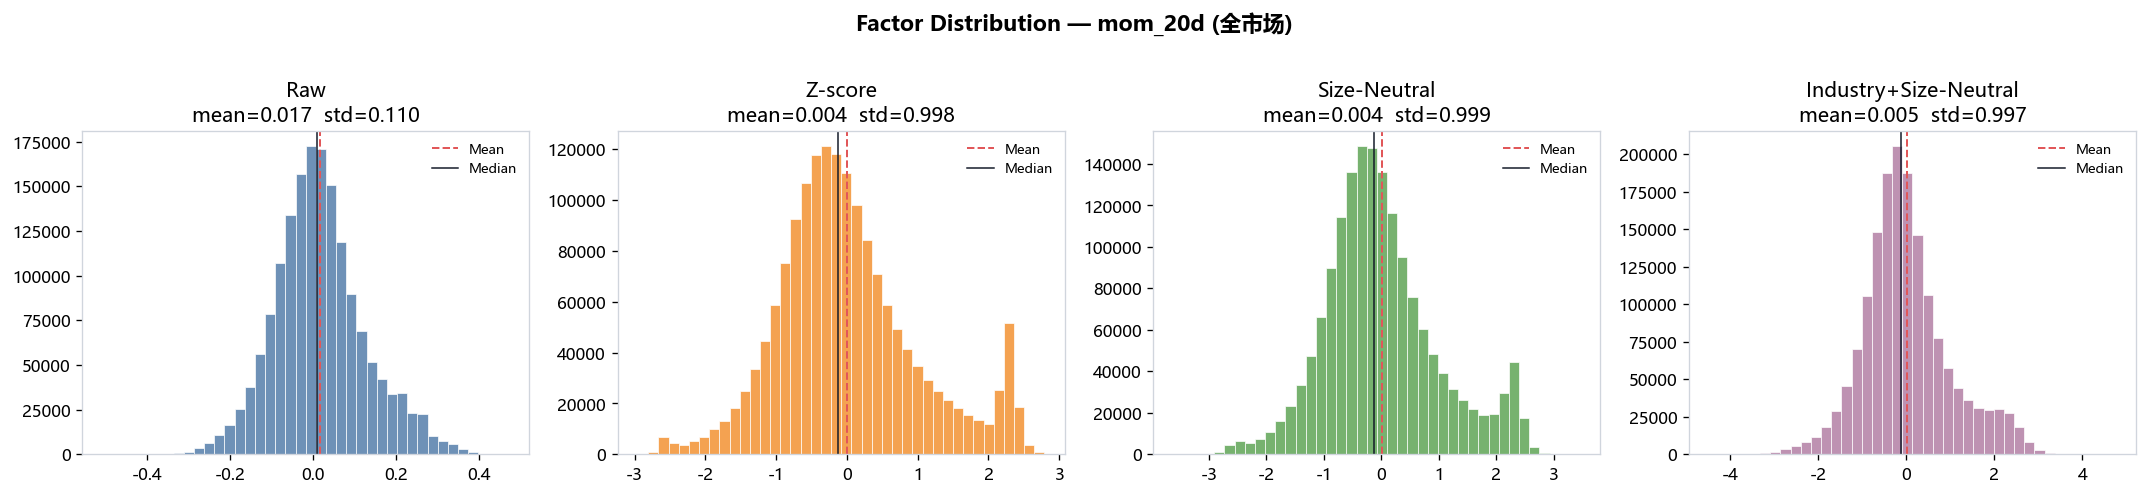

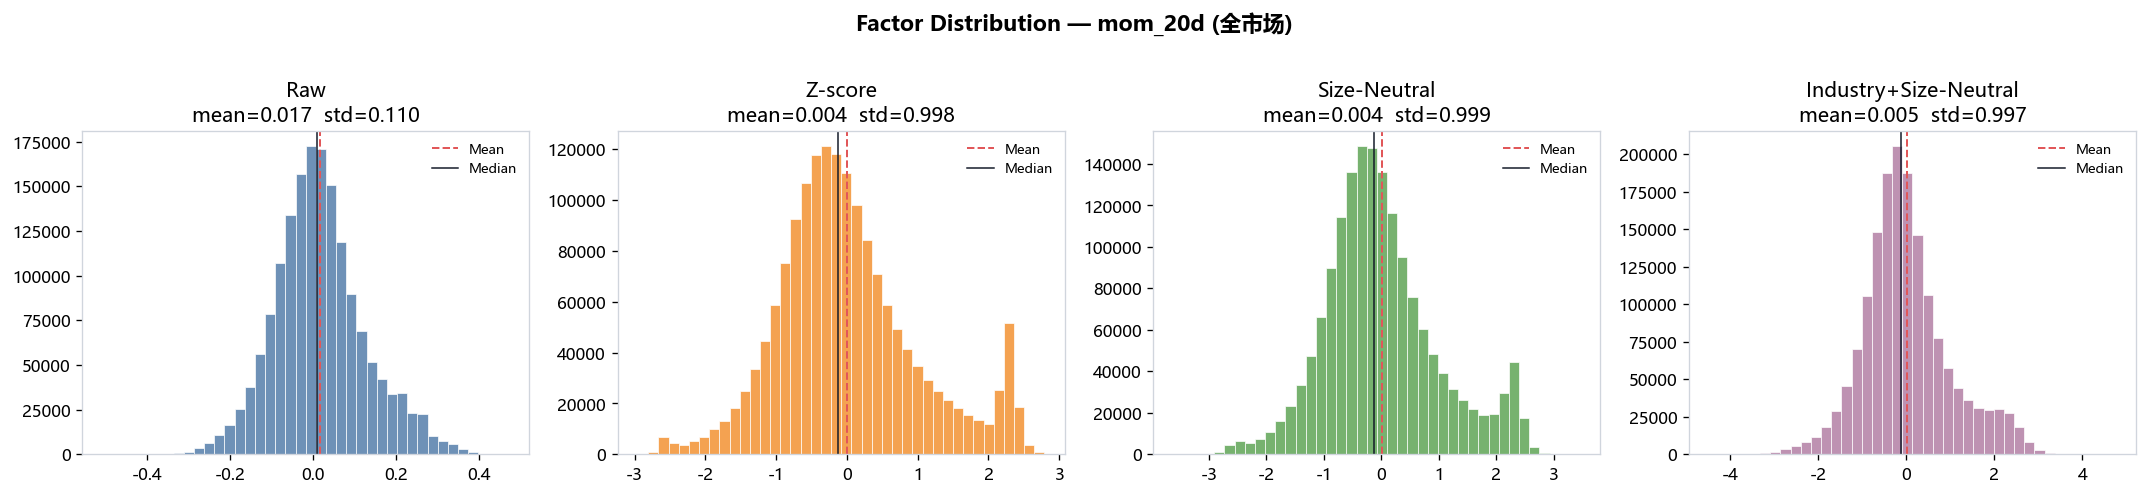

In [4]:
display(plot_distribution(result))


---
## 4. IC 分析


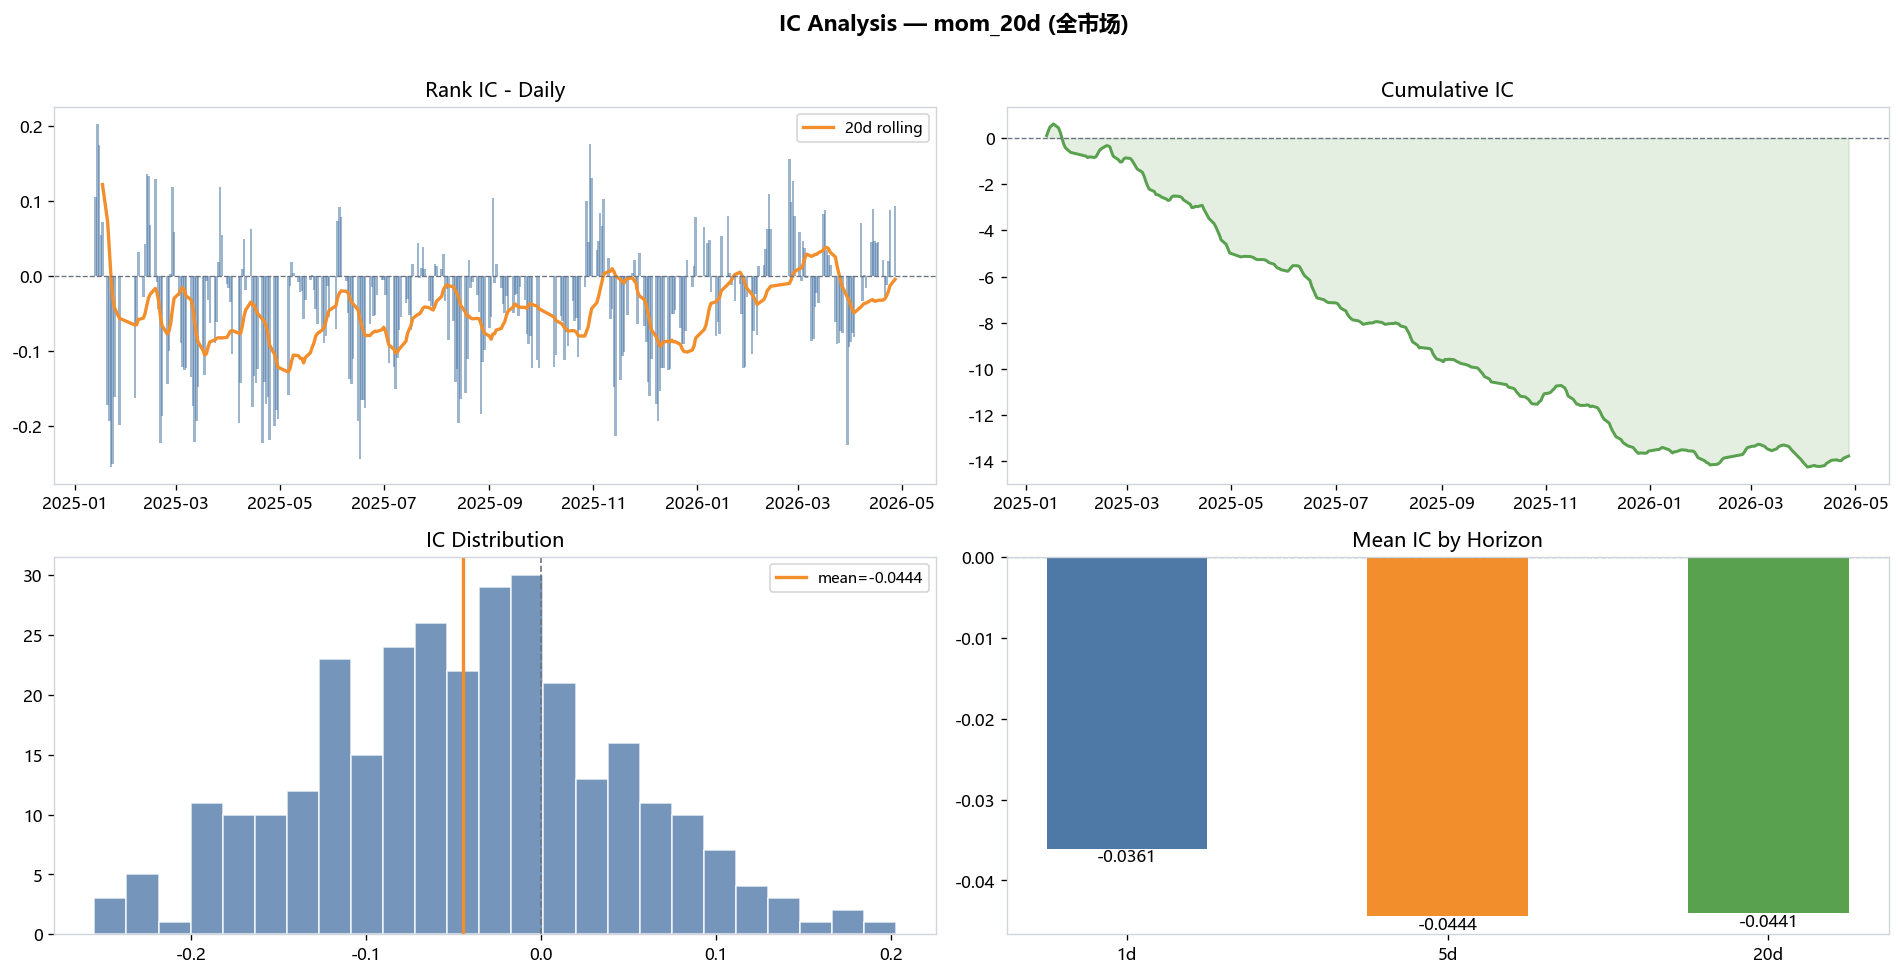

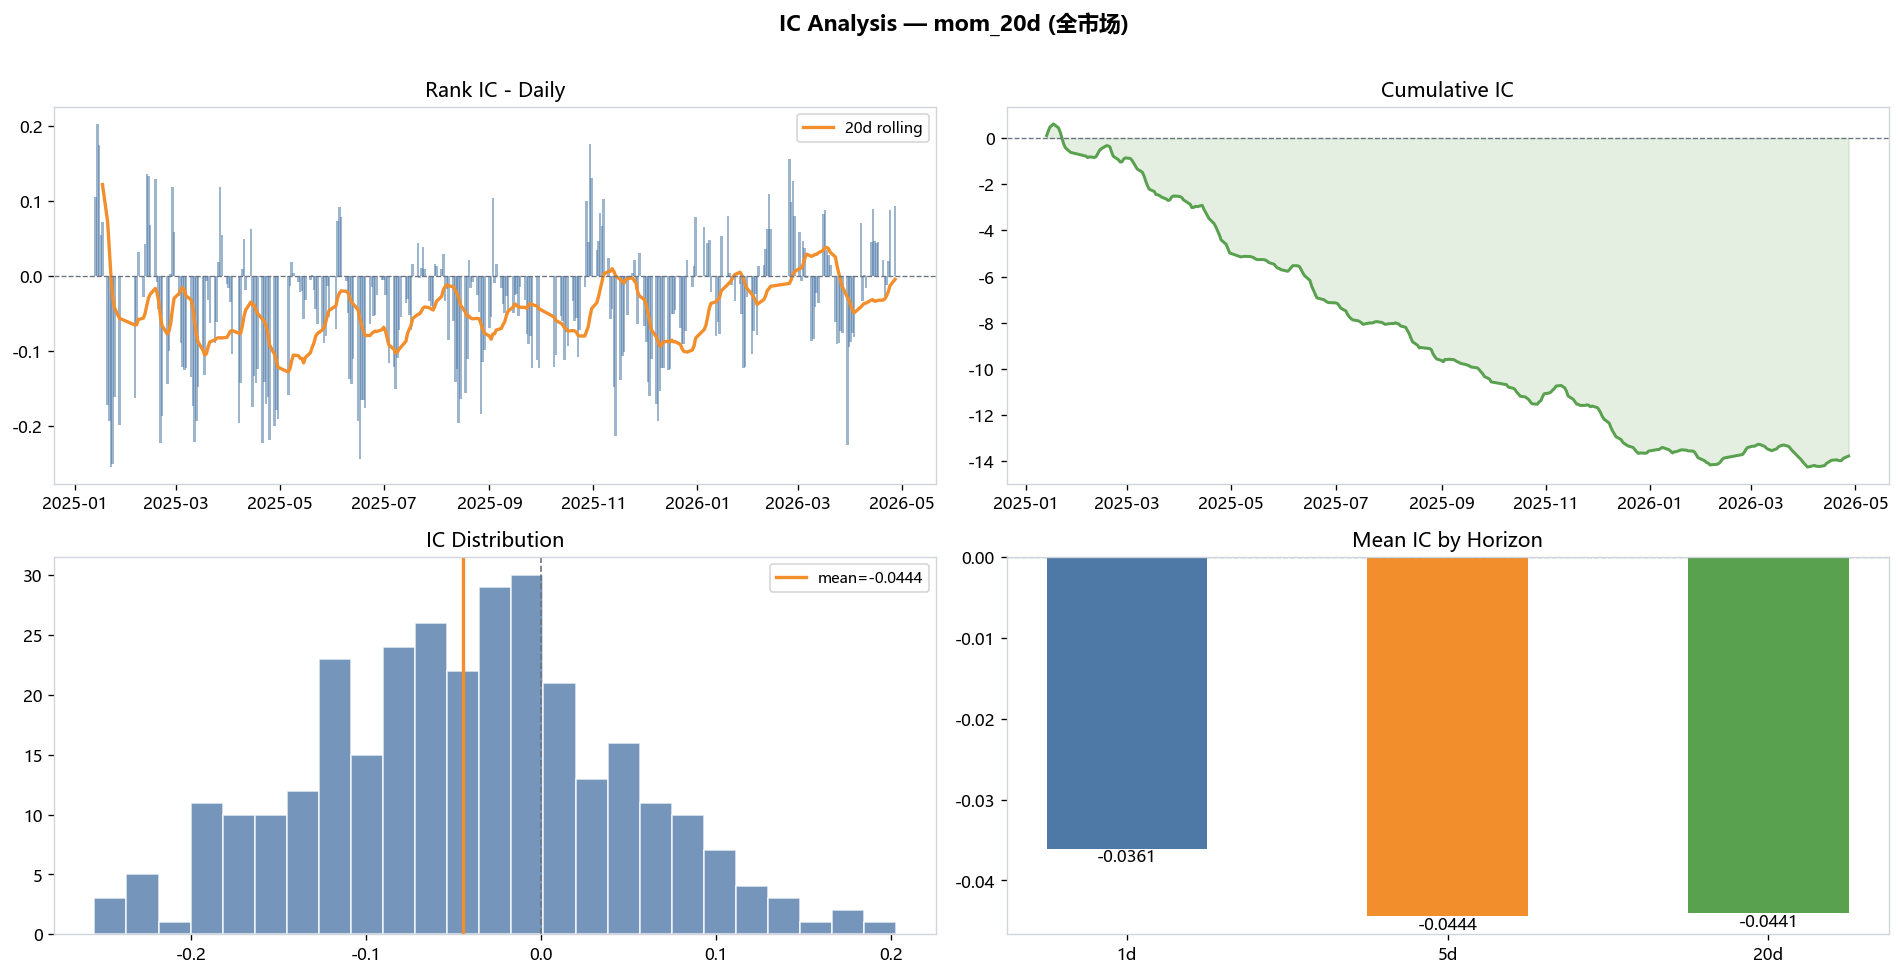

In [5]:
display(plot_ic(result))


---
## 5. IC 衰减


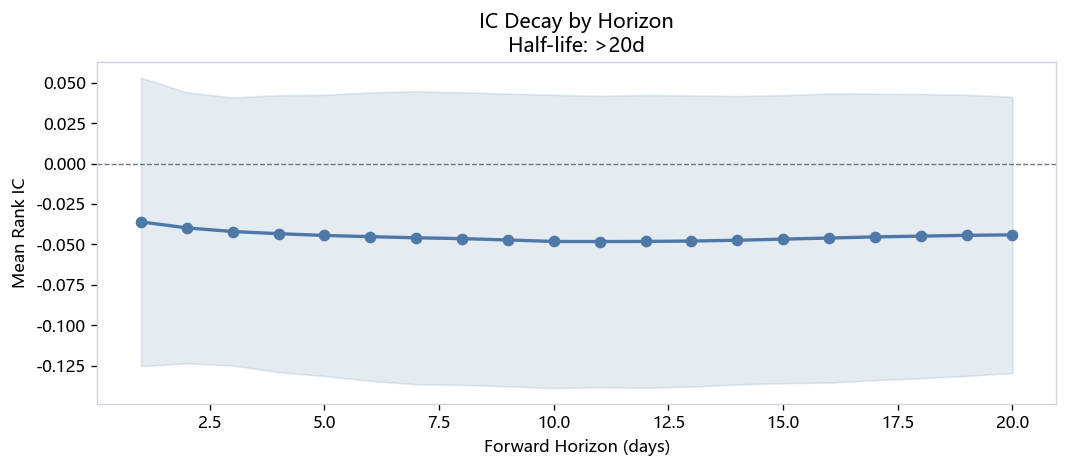

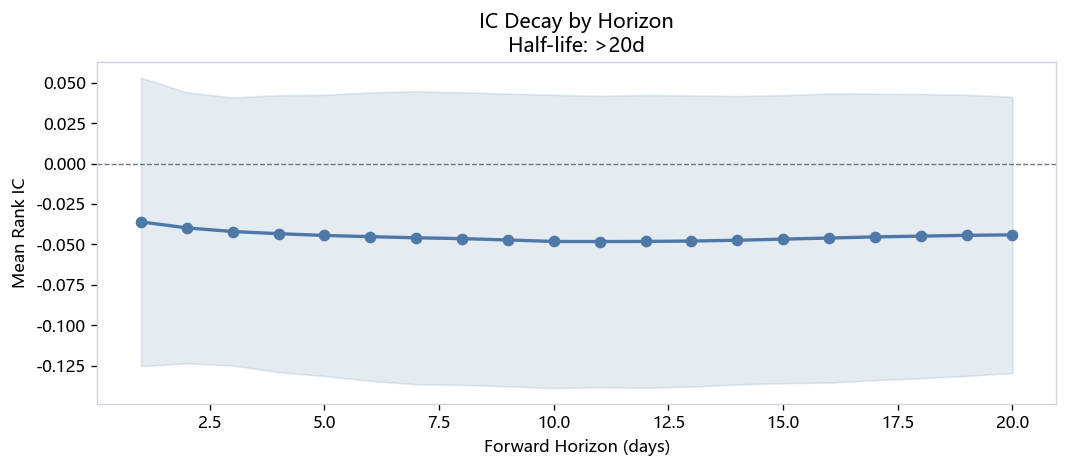

In [6]:
display(plot_ic_decay(result))


---
## 6. 回归法 t 检验

每期横截面 OLS `fwd_5d ~ factor`，检验因子收益率是否统计显著。
- 左：每期因子收益率（OLS beta）
- 中：每期 t 值，橙色线是 |t|=2
- 右：t 值分布

|t| 均值大、|t|>2 占比高 → 因子在统计上显著。


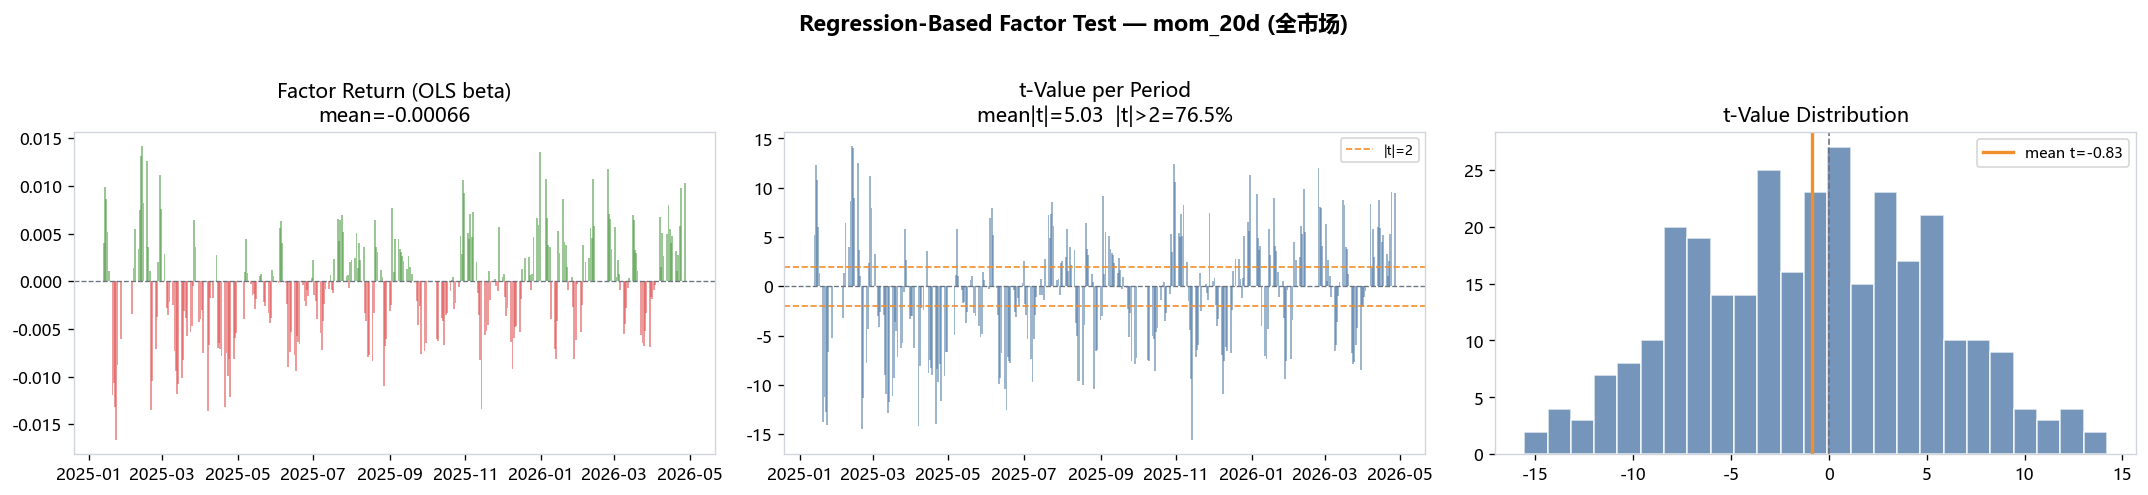

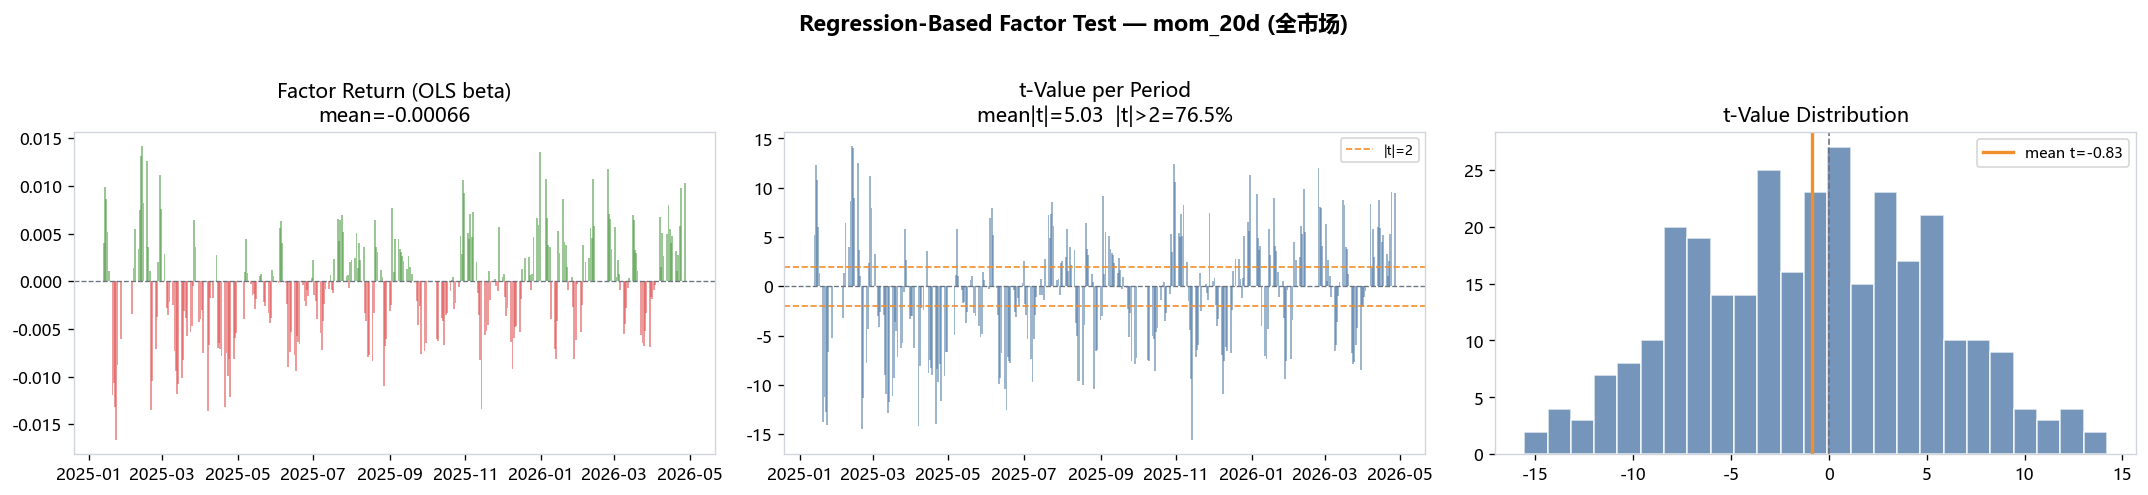

In [7]:
display(plot_regression_test(result))


---
## 7. 月度 IC 热力图

年×月 IC 均值，快速发现因子在某些月份是否系统性失效。


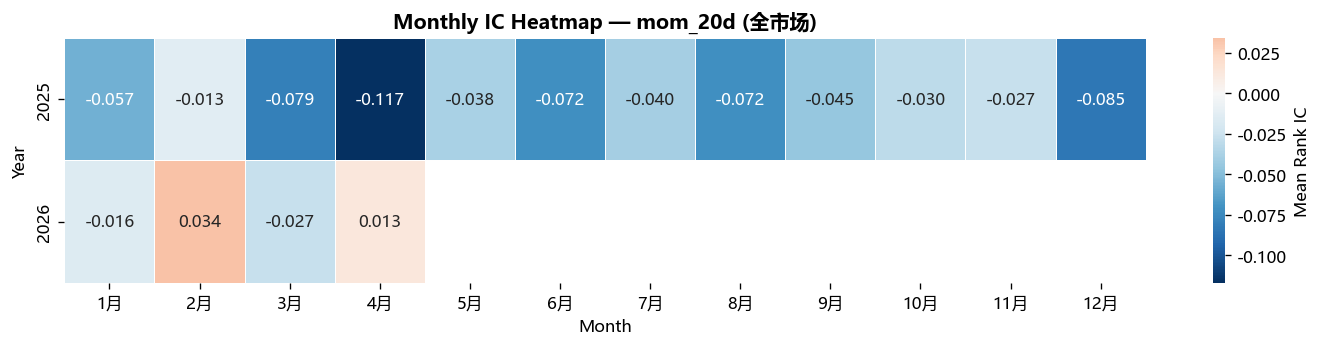

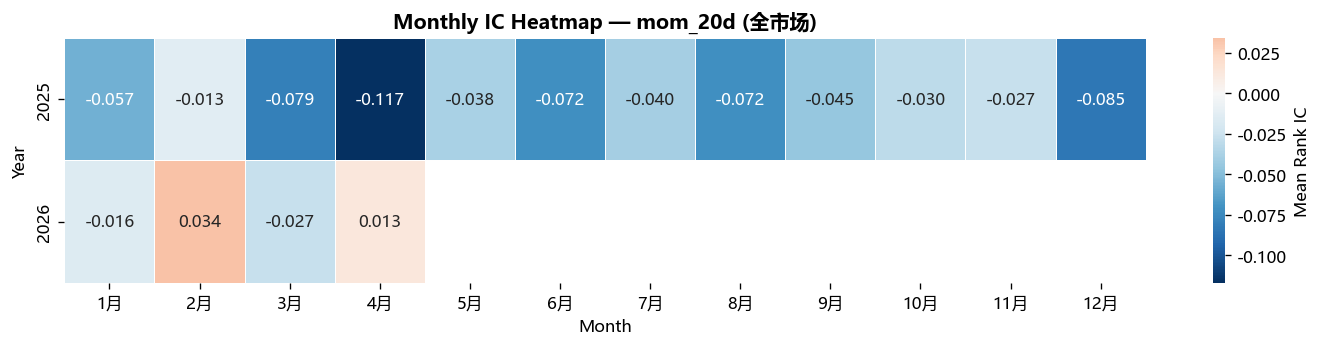

In [8]:
display(plot_monthly_ic_heatmap(result))


---
## 8. 分层收益

每天按因子值分成 Q1（低）~ Q5（高）5 组，看各组未来收益。
- 左：各组平均收益
- 右：各组累计收益曲线

理想形态：Q1→Q5 单调递增，Q5 长期跑在 Q1 上方。


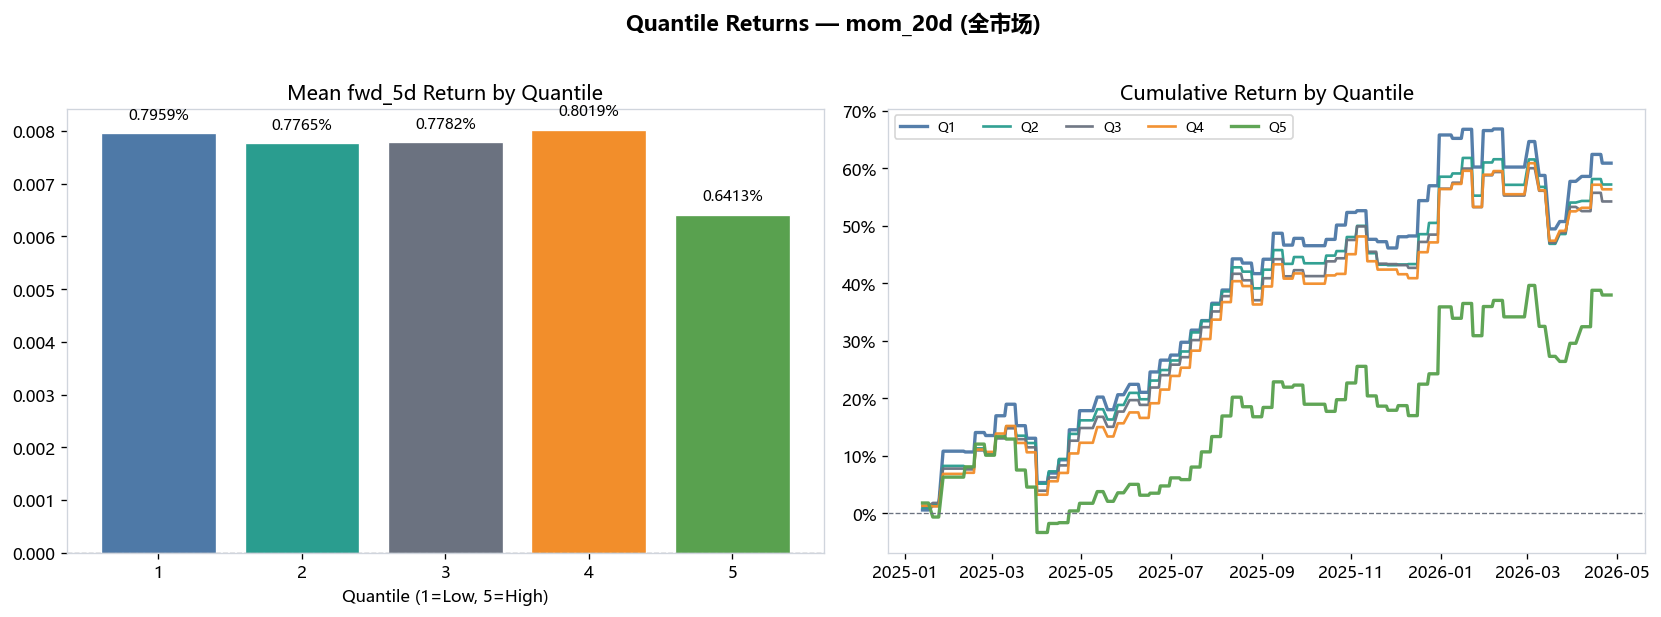

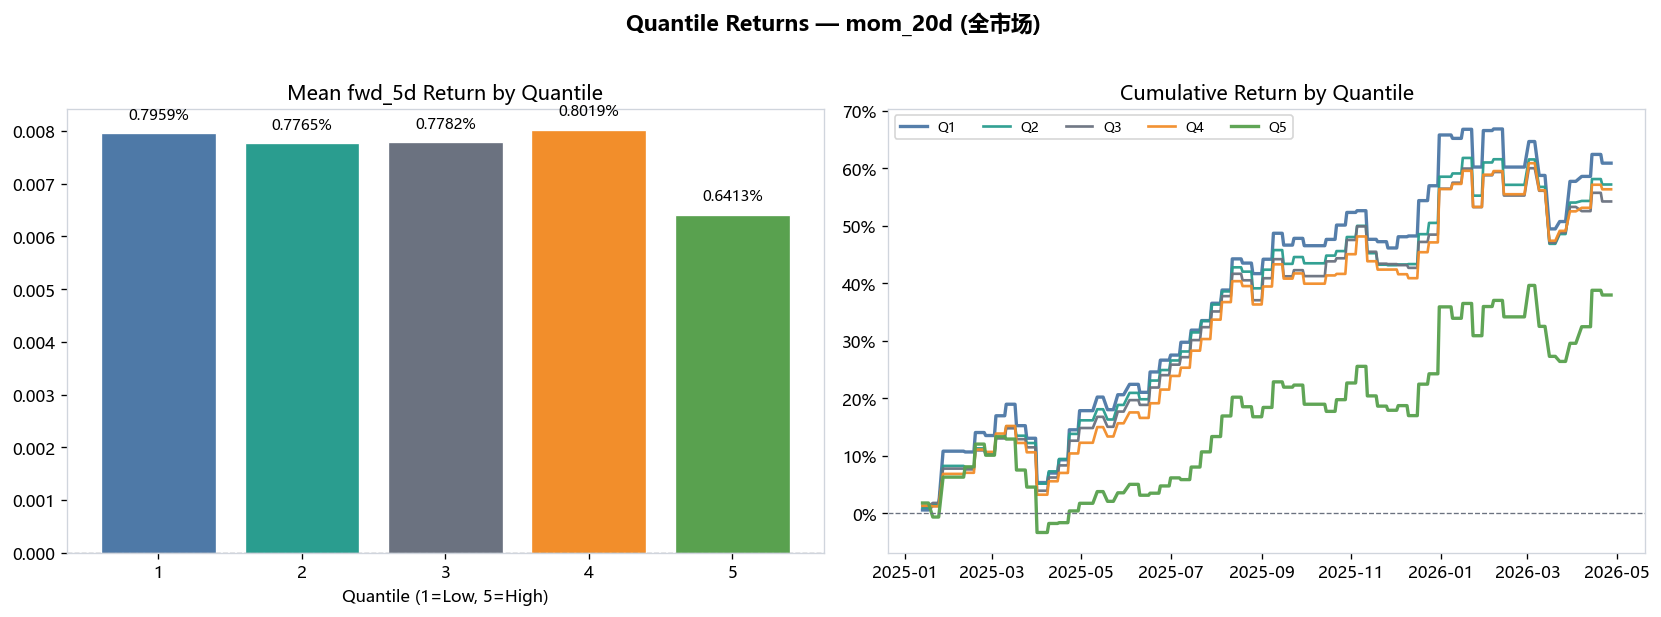

In [9]:
display(plot_quantile_returns(result))


---
## 9. 多空收益 (Q5−Q1)

买 Q5、卖 Q1 的日度 spread 和累计曲线，以及 Sharpe/Calmar 综合评价。


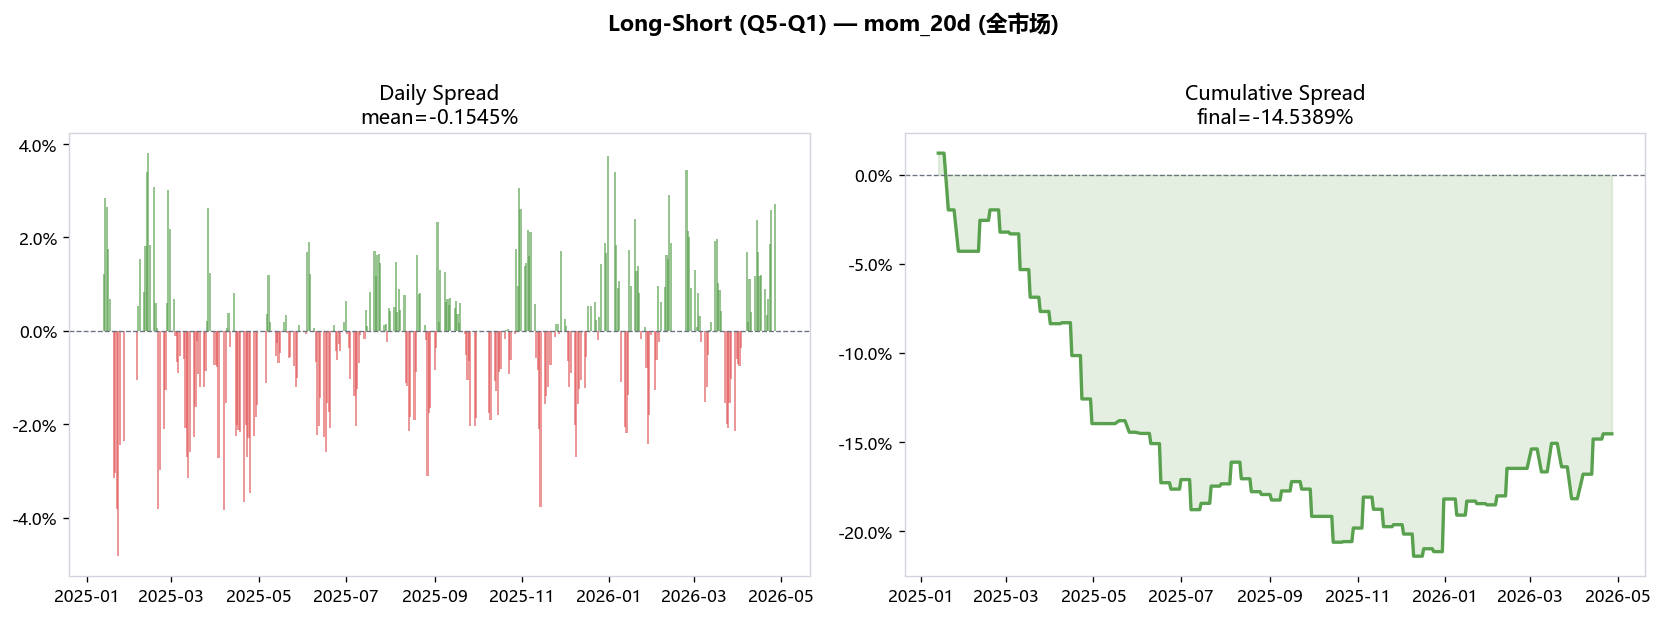

指标,值
Q5-Q1 年化收益率,-38.9414%
Q5-Q1 年化波动率,24.7736%
Q5-Q1 Sharpe,-1.572
Q5-Q1 Calmar,-1.742
Q5-Q1 最大回撤,-22.3492%
Q5-Q1 胜率,47.4%


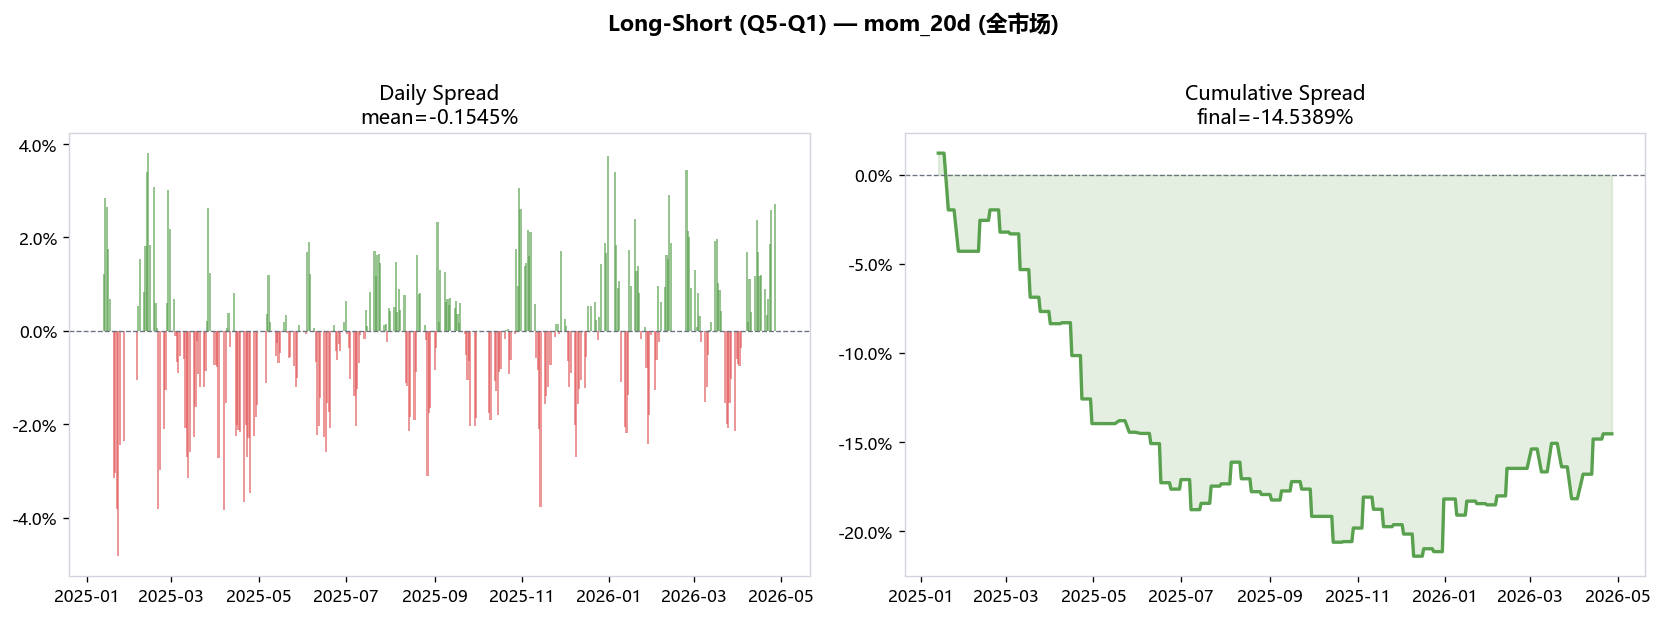

In [10]:
display(plot_long_short(result))

ls = result.long_short_summary
ls_extra = pd.DataFrame([
    ["Q5-Q1 年化收益率", f"{result.long_short_annual_return:.4%}"],
    ["Q5-Q1 年化波动率", f"{result.long_short_annual_vol:.4%}"],
    ["Q5-Q1 Sharpe", f"{result.long_short_sharpe:.3f}"],
    ["Q5-Q1 Calmar", f"{result.long_short_calmar:.3f}"],
    ["Q5-Q1 最大回撤", f"{result.long_short_max_dd:.4%}"],
    ["Q5-Q1 胜率", f"{ls['win_rate']:.1%}"],
], columns=["指标", "值"])
display(ls_extra.style.hide(axis="index"))


---
## 10. 年度业绩


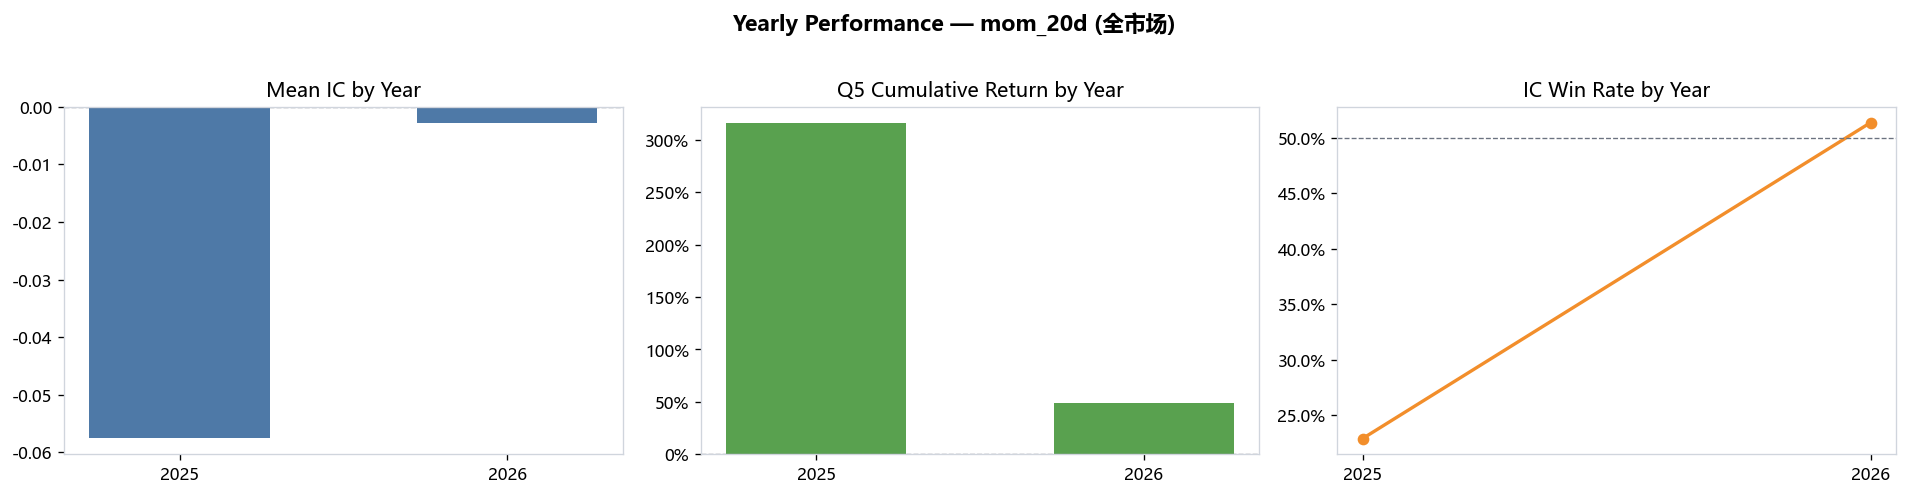

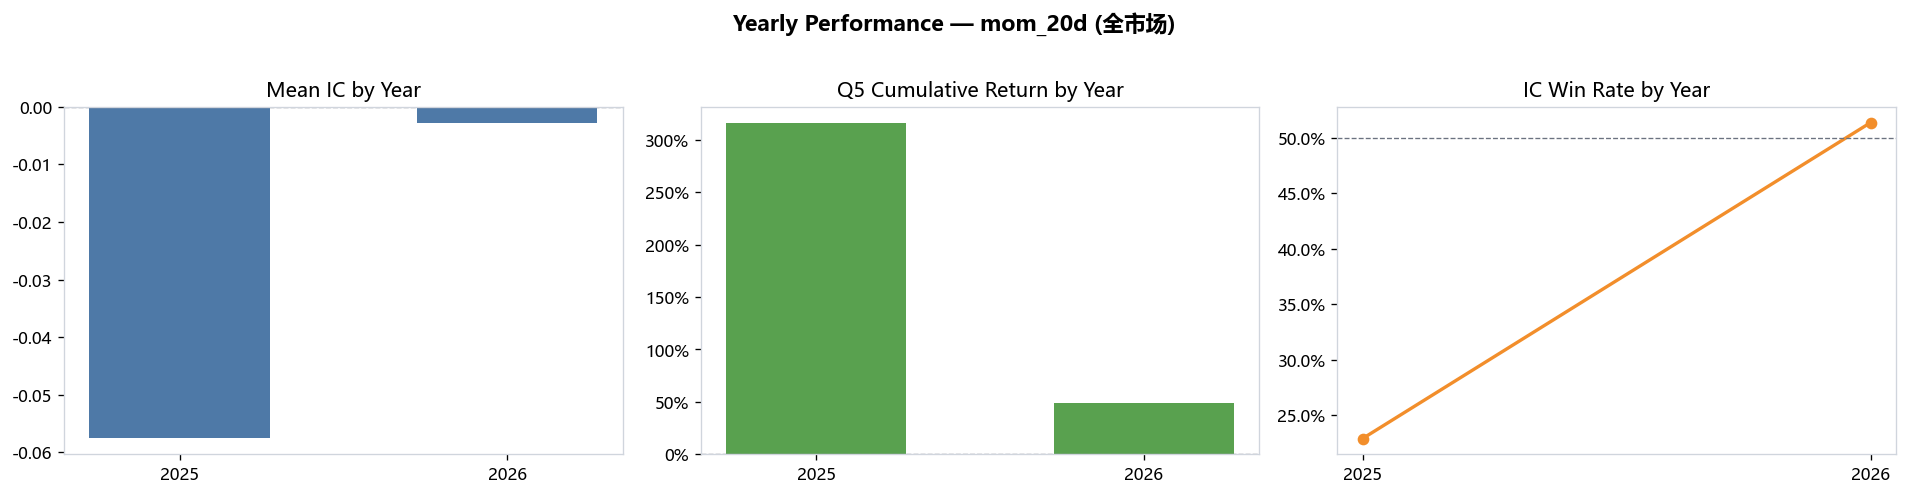

In [11]:
display(plot_yearly_perf(result))


---
## 11. Q5 轻量回测

这不代表真实交易——只是把 Q5 高分组转成轻量组合视图，看信号在扣除调仓成本后是否还站得住。

- 组合：只做多 Q5，等权
- 调仓：每 5 个交易日
- 成本：双边 `2 × turnover × one_way_cost`（默认单边 0.1%）


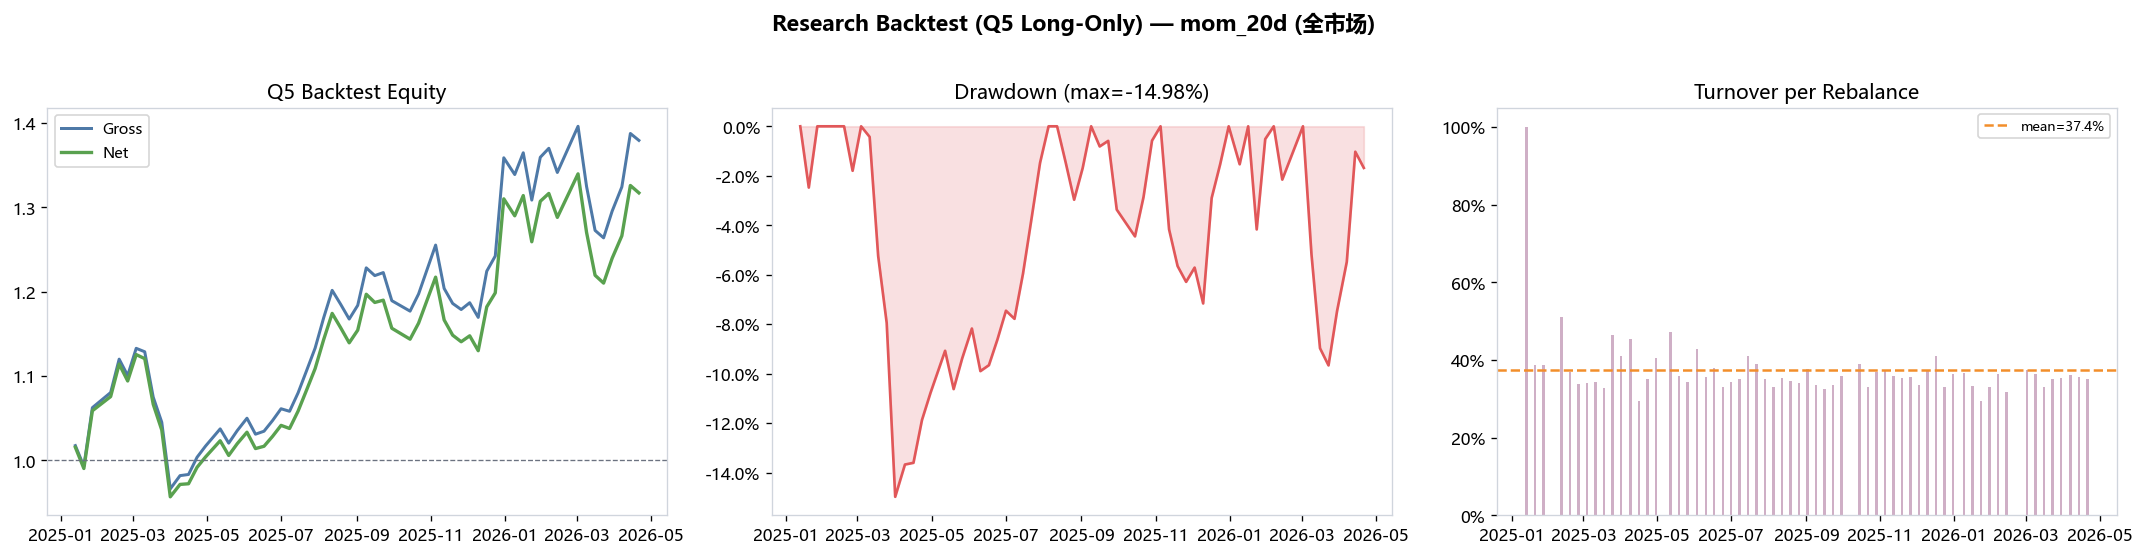

Metric,Value,Judgement
Q5 调仓次数,62,-
Q5 平均持仓数,1063.6,-
Q5 累计净值 (净),1.3173,-
Q5 年化收益率,25.1112%,Pass
Q5 年化波动率,20.8584%,-
Q5 Sharpe,1.204,-
Q5 Calmar,1.676,-
Q5 最大回撤,-14.9829%,-
Q5 平均换手率,37.4%,-
Q5 平均交易成本,0.0748%,-


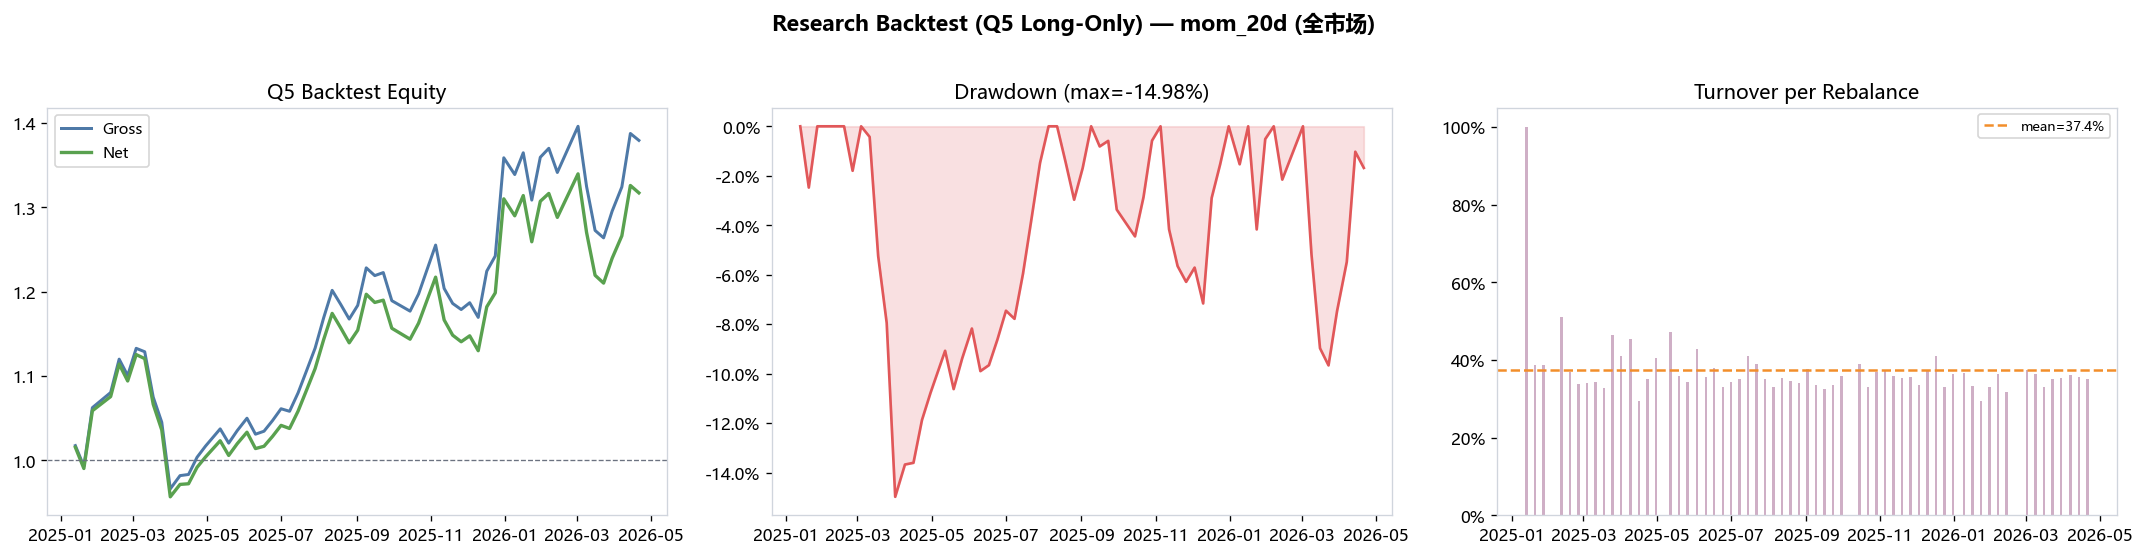

In [12]:
display(plot_backtest(result))
display(result.backtest_summary.style.hide(axis="index"))


---
## 12. 结论与分析

### 判断标准参考

| 指标 | 强 | 可接受 | 弱 |
|------|-----|--------|-----|
| Mean IC | > 0.03 | 0.01~0.03 | < 0.01 |
| IC IR | > 0.5 | 0.2~0.5 | < 0.2 |
| IC Win Rate | > 55% | 50%~55% | < 50% |
| |t|>2 占比 | > 40% | 30%~40% | < 30% |
| Q5-Q1 Sharpe | > 1.0 | 0.5~1.0 | < 0.5 |
| Q5-Q1 Calmar | > 1.0 | 0.5~1.0 | < 0.5 |
| 单调性 | 严格单调 | 大致单调 | 混乱 |
| IC Half-life | > 10d | 5~10d | < 5d |

### 阅读顺序

1. 先看评分卡（§2），一页判断因子整体质量
2. 如果 IC 方向不符合预期，看 IC 分析（§4）和 IC 衰减（§5）
3. 如果 IC 还行但多空收益差，看分层收益（§8）——可能中间组乱序
4. 如果分层 OK 但回测差，看换手率和成本敏感性——可能被交易成本吃掉
5. 月度热力图（§7）检查季节性失效；年度业绩（§10）检查年份一致性

### 下一步
- 如果因子通过大部分 Pass 判定，可以进入 01 notebook 做更细的手动研究
- 如果想横向对比多个因子，复制这个 notebook 改 `FACTOR_KWARGS` 即可
- 如果 IC 方向对但强度不够，考虑换窗口参数或和其他因子合成
